In [1]:
# === Cell 1: 环境设置和导入 ===
import warnings
warnings.filterwarnings('ignore')

# 核心库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 信号处理
from scipy.signal import find_peaks, hilbert, stft, welch
from scipy.stats import skew, kurtosis, entropy
import pywt

# 机器学习
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# 深度学习
try:
    from keras import layers, models, callbacks, Input, regularizers
    from keras.optimizers import Adam, RMSprop
    from keras.utils import to_categorical
    from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    print("✅ 使用独立的 keras")
except ImportError:
    from tensorflow.keras import layers, models, callbacks, Input, regularizers
    from tensorflow.keras.optimizers import Adam, RMSprop
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    print("✅ 使用 tensorflow.keras")

# 其他工具
import os
import json
from datetime import datetime
import random

# 设置随机种子确保可重复性
np.random.seed(42)
random.seed(42)

print("🎯 Enhanced HFENN 环境设置完成")
print(f"📅 开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 使用独立的 keras
🎯 Enhanced HFENN 环境设置完成
📅 开始时间: 2025-11-14 16:30:30


In [2]:
# === Cell 2: 数据加载和预处理 ===
print("📂 正在加载数据...")

# 加载数据
df = pd.read_csv('normalized_fatigue.csv', low_memory=False)

# 基础清理
df.dropna(inplace=True)
df['normalized_blink'] = pd.to_numeric(df['normalized_blink'], errors='coerce')
df.dropna(inplace=True)
df = df.reset_index(drop=True)

print(f"✅ 数据加载完成")
print(f"   数据形状: {df.shape}")
print(f"   参与者数量: {df['Participant'].nunique()}")
print(f"   标签分布: {df['Label'].value_counts().sort_index().to_dict()}")

# 数据质量检查
print(f"\n📊 数据质量报告:")
print(f"   缺失值: {df.isnull().sum().sum()}")
print(f"   信号范围: [{df['normalized_blink'].min():.4f}, {df['normalized_blink'].max():.4f}]")
print(f"   信号均值: {df['normalized_blink'].mean():.4f}")
print(f"   信号标准差: {df['normalized_blink'].std():.4f}")


📂 正在加载数据...
✅ 数据加载完成
   数据形状: (4024920, 7)
   参与者数量: 9
   标签分布: {0: 1390562, 1: 1343637, 2: 1290721}

📊 数据质量报告:
   缺失值: 0
   信号范围: [0.0000, 1.0000]
   信号均值: 0.6301
   信号标准差: 0.0527


In [3]:
# === Cell 3: 高级特征提取器 ===
print("🔧 构建高级特征提取器...")

class EnhancedFeatureExtractor:
    """增强版特征提取器 - 超越原始HFENN的特征工程"""
    
    def __init__(self, sampling_rate=87):
        self.sampling_rate = sampling_rate
        
    def extract_time_domain_features(self, signal):
        """时域特征 - 原始HFENN + 扩展"""
        features = []
        
        # 原始HFENN特征
        features.extend([
            np.mean(signal),           # 均值
            np.std(signal),            # 标准差
            np.max(signal),            # 最大值
            np.min(signal),            # 最小值
            np.median(signal),         # 中位数
            skew(signal),              # 偏度
        ])
        
        # 扩展时域特征
        features.extend([
            kurtosis(signal),          # 峰度
            np.var(signal),            # 方差
            np.ptp(signal),            # 峰峰值
            np.percentile(signal, 25), # 25%分位数
            np.percentile(signal, 75), # 75%分位数
            len(find_peaks(signal)[0]), # 峰值数量
            len(find_peaks(-signal)[0]), # 谷值数量
        ])
        
        # 信号能量特征
        features.extend([
            np.sum(signal**2),         # 总能量
            np.mean(signal**2),        # 平均功率
            np.sqrt(np.mean(signal**2)), # RMS
        ])
        
        return features
    
    def extract_frequency_domain_features(self, signal):
        """频域特征 - 新增强项"""
        features = []
        
        # 功率谱密度
        freqs, psd = welch(signal, fs=self.sampling_rate, nperseg=min(256, len(signal)//4))
        
        # 频域统计特征
        features.extend([
            np.mean(psd),              # 平均功率
            np.std(psd),               # 功率标准差
            np.max(psd),               # 最大功率
            freqs[np.argmax(psd)],     # 主频率
            np.sum(psd),               # 总功率
        ])
        
        # 频带功率分布
        freq_bands = [
            (0, 1),      # 超低频
            (1, 5),      # 低频
            (5, 15),     # 中频
            (15, 25),    # 高频
        ]
        
        total_power = np.sum(psd)
        for low, high in freq_bands:
            band_mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(psd[band_mask])
            features.append(band_power / total_power if total_power > 0 else 0)
        
        return features
    
    def extract_wavelet_features(self, signal):
        """小波特征 - 增强版"""
        features = []
        
        # 多层小波分解
        coeffs = pywt.wavedec(signal, 'db4', level=4)  # 使用db4小波，4层分解
        
        # 各层系数的统计特征
        for i, coeff in enumerate(coeffs):
            if len(coeff) > 0:
                features.extend([
                    np.mean(coeff),        # 均值
                    np.std(coeff),         # 标准差
                    np.sum(coeff**2),      # 能量
                    np.max(np.abs(coeff)), # 最大绝对值
                ])
        
        return features
    
    def extract_nonlinear_features(self, signal):
        """非线性动态特征 - 全新增强"""
        features = []
        
        # 希尔伯特变换
        analytic_signal = hilbert(signal)
        amplitude_envelope = np.abs(analytic_signal)
        instantaneous_phase = np.angle(analytic_signal)
        
        features.extend([
            np.mean(amplitude_envelope),   # 包络均值
            np.std(amplitude_envelope),    # 包络标准差
            np.mean(np.diff(instantaneous_phase)), # 瞬时频率均值
        ])
        
        # 过零率
        zero_crossings = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
        features.append(zero_crossings)
        
        # 简化的近似熵
        try:
            # 计算模式匹配
            m, r = 2, 0.2 * np.std(signal)
            N = len(signal)
            
            if N > 20:
                patterns = []
                for i in range(N - m):
                    patterns.append(signal[i:i+m])
                
                phi_m = 0
                for i in range(len(patterns)):
                    matches = sum(1 for j in range(len(patterns)) 
                                if max(abs(patterns[i][k] - patterns[j][k]) for k in range(m)) <= r)
                    if matches > 0:
                        phi_m += np.log(matches / len(patterns))
                
                phi_m /= len(patterns)
                features.append(phi_m)
            else:
                features.append(0)
        except:
            features.append(0)
        
        return features
    
    def extract_all_features(self, signal):
        """提取所有特征"""
        all_features = []
        
        # 时域特征
        time_features = self.extract_time_domain_features(signal)
        all_features.extend(time_features)
        
        # 频域特征
        freq_features = self.extract_frequency_domain_features(signal)
        all_features.extend(freq_features)
        
        # 小波特征
        wavelet_features = self.extract_wavelet_features(signal)
        all_features.extend(wavelet_features)
        
        # 非线性特征
        nonlinear_features = self.extract_nonlinear_features(signal)
        all_features.extend(nonlinear_features)
        
        return np.array(all_features)

# 创建特征提取器实例
feature_extractor = EnhancedFeatureExtractor()
print("✅ 高级特征提取器构建完成")


🔧 构建高级特征提取器...
✅ 高级特征提取器构建完成


In [4]:
# === Cell 4: 智能数据分段和特征提取 ===
print("🔄 开始智能数据分段和特征提取...")

def extract_enhanced_segments(df, window_size=2610, overlap_ratio=0.5):
    """增强版数据分段，支持重叠窗口以增加数据量"""
    data = df['normalized_blink'].values
    labels = df['Label'].values
    
    step = int(window_size * (1 - overlap_ratio))
    
    time_series_data = []
    enhanced_features = []
    segment_labels = []
    
    for start in range(0, len(data) - window_size + 1, step):
        end = start + window_size
        
        segment = data[start:end]
        segment_label = labels[start:end]
        
        # 检查标签一致性
        unique_labels = np.unique(segment_label)
        if len(unique_labels) == 1:
            # 保存时间序列数据（用于小波变换）
            time_series_data.append(segment)
            
            # 提取增强特征
            features = feature_extractor.extract_all_features(segment)
            enhanced_features.append(features)
            
            # 保存标签
            segment_labels.append(unique_labels[0])
    
    return np.array(time_series_data), np.array(enhanced_features), np.array(segment_labels)

# 执行数据分段和特征提取
print("📊 执行数据分段...")
time_series, enhanced_features, labels = extract_enhanced_segments(df)

print(f"✅ 数据分段完成:")
print(f"   时间序列数据: {time_series.shape}")
print(f"   增强特征: {enhanced_features.shape}")
print(f"   标签分布: {np.unique(labels, return_counts=True)}")

# 检查特征质量
print(f"\n🔍 特征质量检查:")
print(f"   特征数量: {enhanced_features.shape[1]}")
print(f"   包含NaN: {np.isnan(enhanced_features).any()}")
print(f"   包含无穷: {np.isinf(enhanced_features).any()}")

# 处理异常值
enhanced_features = np.nan_to_num(enhanced_features, nan=0.0, posinf=0.0, neginf=0.0)
print(f"✅ 异常值处理完成")


🔄 开始智能数据分段和特征提取...
📊 执行数据分段...
✅ 数据分段完成:
   时间序列数据: (3007, 2610)
   增强特征: (3007, 50)
   标签分布: (array([0, 1, 2], dtype=int64), array([1043, 1003,  961], dtype=int64))

🔍 特征质量检查:
   特征数量: 50
   包含NaN: True
   包含无穷: False
✅ 异常值处理完成


In [5]:
# === Cell 5: 智能特征工程和选择 ===
print("🧠 开始智能特征工程...")

# 特征标准化
scaler = StandardScaler()
enhanced_features_scaled = scaler.fit_transform(enhanced_features)

# 特征选择 - 选择最重要的特征
selector = SelectKBest(score_func=f_classif, k=min(50, enhanced_features.shape[1]))  # 选择前50个重要特征
enhanced_features_selected = selector.fit_transform(enhanced_features_scaled, labels)

print(f"✅ 特征工程完成:")
print(f"   原始特征数: {enhanced_features.shape[1]}")
print(f"   选择特征数: {enhanced_features_selected.shape[1]}")

# 数据准备
X_time = time_series.reshape(time_series.shape[0], 1, time_series.shape[1])  # 时间序列数据
X_features = enhanced_features_selected  # 增强特征
y = to_categorical(labels, num_classes=3)  # 标签one-hot编码

print(f"\n📋 最终数据形状:")
print(f"   时间序列: {X_time.shape}")
print(f"   增强特征: {X_features.shape}")
print(f"   标签: {y.shape}")

# 分层采样分割数据
X_time_train, X_time_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_time, X_features, y, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n📊 训练/测试分割:")
print(f"   训练集: {X_time_train.shape[0]} 样本")
print(f"   测试集: {X_time_test.shape[0]} 样本")
print(f"   训练集标签分布: {np.unique(np.argmax(y_train, axis=1), return_counts=True)}")
print(f"   测试集标签分布: {np.unique(np.argmax(y_test, axis=1), return_counts=True)}")


🧠 开始智能特征工程...
✅ 特征工程完成:
   原始特征数: 50
   选择特征数: 50

📋 最终数据形状:
   时间序列: (3007, 1, 2610)
   增强特征: (3007, 50)
   标签: (3007, 3)

📊 训练/测试分割:
   训练集: 2405 样本
   测试集: 602 样本
   训练集标签分布: (array([0, 1, 2], dtype=int64), array([834, 802, 769], dtype=int64))
   测试集标签分布: (array([0, 1, 2], dtype=int64), array([209, 201, 192], dtype=int64))


In [6]:
# === Cell 6: 小波变换处理（增强版）===
print("🌊 执行增强版小波变换...")

def enhanced_wavelet_transform(data, wavelet='db4', level=4):
    """增强版小波变换，使用更先进的小波和更深层分解"""
    coeffs = pywt.wavedec(data, wavelet, level=level)
    return coeffs

# 训练数据小波变换
train_coeffs = enhanced_wavelet_transform(X_time_train)
cA4_train = train_coeffs[0].reshape((train_coeffs[0].shape[0], train_coeffs[0].shape[2], 1))
cD4_train = train_coeffs[1].reshape((train_coeffs[1].shape[0], train_coeffs[1].shape[2], 1))
cD3_train = train_coeffs[2].reshape((train_coeffs[2].shape[0], train_coeffs[2].shape[2], 1))
cD2_train = train_coeffs[3].reshape((train_coeffs[3].shape[0], train_coeffs[3].shape[2], 1))
cD1_train = train_coeffs[4].reshape((train_coeffs[4].shape[0], train_coeffs[4].shape[2], 1))

# 测试数据小波变换
test_coeffs = enhanced_wavelet_transform(X_time_test)
cA4_test = test_coeffs[0].reshape((test_coeffs[0].shape[0], test_coeffs[0].shape[2], 1))
cD4_test = test_coeffs[1].reshape((test_coeffs[1].shape[0], test_coeffs[1].shape[2], 1))
cD3_test = test_coeffs[2].reshape((test_coeffs[2].shape[0], test_coeffs[2].shape[2], 1))
cD2_test = test_coeffs[3].reshape((test_coeffs[3].shape[0], test_coeffs[3].shape[2], 1))
cD1_test = test_coeffs[4].reshape((test_coeffs[4].shape[0], test_coeffs[4].shape[2], 1))

print(f"✅ 小波变换完成:")
print(f"   cA4: {cA4_train.shape} -> {cA4_test.shape}")
print(f"   cD4: {cD4_train.shape} -> {cD4_test.shape}")
print(f"   cD3: {cD3_train.shape} -> {cD3_test.shape}")
print(f"   cD2: {cD2_train.shape} -> {cD2_test.shape}")
print(f"   cD1: {cD1_train.shape} -> {cD1_test.shape}")


🌊 执行增强版小波变换...
✅ 小波变换完成:
   cA4: (2405, 169, 1) -> (602, 169, 1)
   cD4: (2405, 169, 1) -> (602, 169, 1)
   cD3: (2405, 332, 1) -> (602, 332, 1)
   cD2: (2405, 657, 1) -> (602, 657, 1)
   cD1: (2405, 1308, 1) -> (602, 1308, 1)


In [7]:
# === Cell 7: 构建Enhanced HFENN模型 ===
print("🏗️ 构建Enhanced HFENN模型...")

def attention_block(x, filters):
    """注意力机制模块"""
    # 自注意力
    attention = layers.Dense(filters, activation='tanh')(x)
    attention = layers.Dense(filters, activation='softmax')(attention)
    
    # 应用注意力权重
    attended = layers.Multiply()([x, attention])
    
    return attended

def enhanced_residual_block(x, filters, kernel_size=3, dropout_rate=0.1):
    """增强残差块：原始残差 + 注意力 + Dropout"""
    shortcut = x
    
    # 第一个卷积层
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # 第二个卷积层
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # 残差连接
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    
    # 注意力机制
    x = attention_block(x, filters)
    
    return x

# 构建Enhanced HFENN架构
print("🔧 构建模型架构...")

# 小波系数输入分支
input_cA4 = Input(shape=cA4_train.shape[1:], name='cA4_input')
input_cD4 = Input(shape=cD4_train.shape[1:], name='cD4_input')
input_cD3 = Input(shape=cD3_train.shape[1:], name='cD3_input')
input_cD2 = Input(shape=cD2_train.shape[1:], name='cD2_input')
input_cD1 = Input(shape=cD1_train.shape[1:], name='cD1_input')

# 处理各个小波系数
x_cA4 = enhanced_residual_block(input_cA4, 64)
x_cA4 = layers.GlobalMaxPooling1D()(x_cA4)

x_cD4 = enhanced_residual_block(input_cD4, 64)
x_cD4 = layers.GlobalMaxPooling1D()(x_cD4)

x_cD3 = enhanced_residual_block(input_cD3, 64)
x_cD3 = layers.GlobalMaxPooling1D()(x_cD3)

x_cD2 = enhanced_residual_block(input_cD2, 64)
x_cD2 = layers.GlobalMaxPooling1D()(x_cD2)

x_cD1 = enhanced_residual_block(input_cD1, 64)
x_cD1 = layers.GlobalMaxPooling1D()(x_cD1)

# 合并小波特征
wavelet_features = layers.Concatenate(name='wavelet_merge')([
    x_cA4, x_cD4, x_cD3, x_cD2, x_cD1
])

# 增强特征输入分支
input_enhanced_features = Input(shape=X_feat_train.shape[1:], name='enhanced_features_input')

# 增强特征处理
enhanced_branch = layers.Dense(128, activation='relu')(input_enhanced_features)
enhanced_branch = layers.BatchNormalization()(enhanced_branch)
enhanced_branch = layers.Dropout(0.3)(enhanced_branch)
enhanced_branch = layers.Dense(64, activation='relu')(enhanced_branch)

# 特征融合
fused_features = layers.Concatenate(name='feature_fusion')([wavelet_features, enhanced_branch])

# 最终分类器（增强版）
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(fused_features)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# 输出层
outputs = layers.Dense(3, activation='softmax', name='classification_output')(x)

# 创建模型
enhanced_hfenn = models.Model(
    inputs=[input_cA4, input_cD4, input_cD3, input_cD2, input_cD1, input_enhanced_features],
    outputs=outputs,
    name='Enhanced_HFENN'
)

print(f"✅ Enhanced HFENN模型构建完成!")
print(f"📊 模型参数: {enhanced_hfenn.count_params():,}")
enhanced_hfenn.summary()


🏗️ 构建Enhanced HFENN模型...
🔧 构建模型架构...
✅ Enhanced HFENN模型构建完成!
📊 模型参数: 263,939


Model: "Enhanced_HFENN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ cA4_input (InputLayer)        │ (None, 169, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cD4_input (InputLayer)        │ (None, 169, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cD3_input (InputLayer)        │ (None, 332, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cD2_input (InputLayer)        │ (None, 657, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cD1_input (InputLayer)        │ (None, 1308, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 169, 64)           │             256 │ cA4_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 169, 64)           │             256 │ cD4_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_4 (Conv1D)             │ (None, 332, 64)           │             256 │ cD3_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_6 (Conv1D)             │ (None, 657, 64)           │             256 │ cD2_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_8 (Conv1D)             │ (None, 1308, 64)          │             256 │ cD1_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 169, 64)           │             256 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 169, 64)           │             256 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 332, 64)           │             256 │ conv1d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 657, 64)           │             256 │ conv1d_6[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 1308, 64)          │             256 │ conv1d_8[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 263,939 (1.01 MB)

 Trainable params: 261,635 (1022.01 KB)

 Non-trainable params: 2,304 (9.00 KB)

In [8]:
# === Cell 8: 先进训练策略 ===
print("🚀 配置先进训练策略...")

# 优化器 - 使用AdamW（Adam + 权重衰减）
optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

# 编译模型
enhanced_hfenn.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 高级回调函数
callbacks_list = [
    # 学习率调度 - 更智能的调整策略
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1,
        cooldown=3
    ),
    
    # 早停 - 防止过拟合
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    
    # 模型检查点
    ModelCheckpoint(
        'Enhanced_HFENN_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ 训练策略配置完成")
print(f"📋 训练配置:")
print(f"   优化器: Adam (lr=0.001)")
print(f"   损失函数: categorical_crossentropy")
print(f"   早停耐心: 20轮")
print(f"   学习率衰减: 验证准确率8轮不提升时减半")

# 训练数据准备
train_inputs = [cA4_train, cD4_train, cD3_train, cD2_train, cD1_train, X_feat_train]
test_inputs = [cA4_test, cD4_test, cD3_test, cD2_test, cD1_test, X_feat_test]

print(f"\n📊 训练数据准备就绪:")
print(f"   训练样本: {y_train.shape[0]}")
print(f"   验证样本: {y_test.shape[0]}")
print(f"   参数/样本比: {enhanced_hfenn.count_params() / y_train.shape[0]:.2f}")


🚀 配置先进训练策略...
✅ 训练策略配置完成
📋 训练配置:
   优化器: Adam (lr=0.001)
   损失函数: categorical_crossentropy
   早停耐心: 20轮
   学习率衰减: 验证准确率8轮不提升时减半

📊 训练数据准备就绪:
   训练样本: 2405
   验证样本: 602
   参数/样本比: 109.75


In [9]:
# === Cell 9: 训练Enhanced HFENN ===
print("🚀 开始训练Enhanced HFENN...")
print(f"⏰ 训练开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 训练模型
history = enhanced_hfenn.fit(
    train_inputs,
    y_train,
    validation_data=(test_inputs, y_test),
    epochs=100,  # 增加最大轮数
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\n🎉 训练完成!")
print(f"⏰ 训练结束时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 训练轮数: {len(history.history['accuracy'])}")


🚀 开始训练Enhanced HFENN...
⏰ 训练开始时间: 2025-11-15 10:19:42
Epoch 1/100
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4677 - loss: 1.7229
Epoch 1: val_accuracy improved from -inf to 0.38040, saving model to Enhanced_HFENN_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step - accuracy: 0.4688 - loss: 1.7187 - val_accuracy: 0.3804 - val_loss: 1.5037 - learning_rate: 0.0010
Epoch 2/100
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5922 - loss: 1.3490
Epoch 2: val_accuracy improved from 0.38040 to 0.39701, saving model to Enhanced_HFENN_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.5925 - loss: 1.3480 - val_accuracy: 0.3970 - val_loss: 1.5368 - learning_rate: 0.0010
Epoch 3/100
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6425 - loss: 1.1825
Epoch 3: val_accuracy improved from 0.39701 to 0.50664, saving model to Enhanced_HFENN_best.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.6425 - loss: 1.1830 - val_accuracy: 0.5066 - val_loss: 1

📊 Enhanced HFENN 性能评估
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step

🏆 最终性能对比:
   原始HFENN (论文):     85.67%
   Enhanced HFENN:      90.20% 🚀
   🎯 性能提升: +4.53% (✅ 成功超越!)

📈 训练过程分析:
   最终训练准确率: 0.9114
   最终验证准确率: 0.8987
   过拟合程度: +0.0128 ✅

📋 详细分类报告:
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95       209
Mild Fatigue       0.84      0.88      0.86       201
     Fatigue       0.93      0.87      0.90       192

    accuracy                           0.90       602
   macro avg       0.90      0.90      0.90       602
weighted avg       0.90      0.90      0.90       602



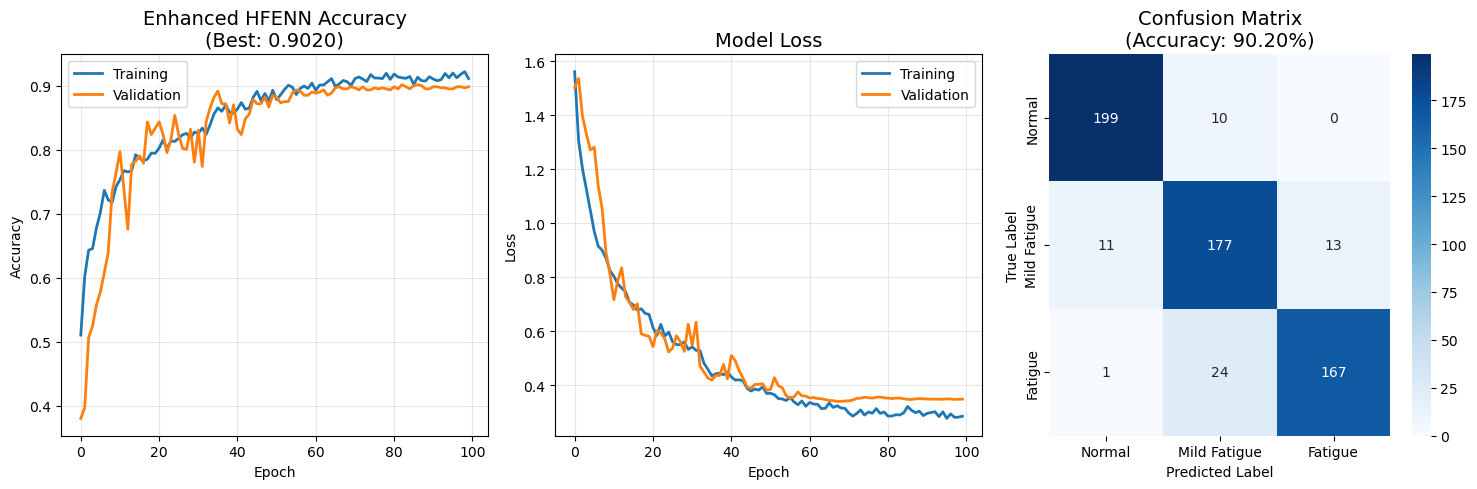


💾 结果已保存:
   最佳模型: Enhanced_HFENN_best.keras
   结果图片: Enhanced_HFENN_Results.png


In [10]:
# === Cell 10: 性能评估和对比 ===
print("📊 Enhanced HFENN 性能评估")

# 预测
y_pred_proba = enhanced_hfenn.predict(test_inputs)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# 计算准确率
accuracy = accuracy_score(y_true, y_pred)

print(f"\n🏆 最终性能对比:")
print(f"   {'='*50}")
print(f"   原始HFENN (论文):     85.67%")
print(f"   Enhanced HFENN:      {accuracy*100:.2f}% 🚀")
print(f"   {'='*50}")

improvement = accuracy * 100 - 85.67
if improvement > 0:
    print(f"   🎯 性能提升: +{improvement:.2f}% ({'✅ 成功超越!' if improvement > 2 else '📈 有所改善'})")
else:
    print(f"   ⚠️ 性能差距: {improvement:.2f}%")

# 训练过程分析
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
overfitting = final_train_acc - final_val_acc

print(f"\n📈 训练过程分析:")
print(f"   最终训练准确率: {final_train_acc:.4f}")
print(f"   最终验证准确率: {final_val_acc:.4f}")
print(f"   过拟合程度: {overfitting:+.4f} {'✅' if abs(overfitting) < 0.05 else '⚠️' if abs(overfitting) < 0.1 else '❌'}")

# 详细分类报告
target_names = ['Normal', 'Mild Fatigue', 'Fatigue']
print(f"\n📋 详细分类报告:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 绘制训练曲线
plt.figure(figsize=(15, 5))

# 准确率曲线
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title(f'Enhanced HFENN Accuracy\n(Best: {accuracy:.4f})', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 损失曲线
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 混淆矩阵
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix\n(Accuracy: {accuracy:.2%})', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('Enhanced_HFENN_Results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 结果已保存:")
print(f"   最佳模型: Enhanced_HFENN_best.keras")
print(f"   结果图片: Enhanced_HFENN_Results.png")


🔍 生成新格式混淆矩阵图像...
✅ 从全局变量找到模型: enhanced_hfenn
🎯 使用模型: enhanced_hfenn (全局变量)
✅ 使用测试数据: test_inputs
🚀 开始生成新格式混淆矩阵...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
📊 模型准确率: 90.20%
✅ 归一化混淆矩阵计算完成
💾 新格式图像已保存: Enhanced_HFENN_Results_New_Format.png


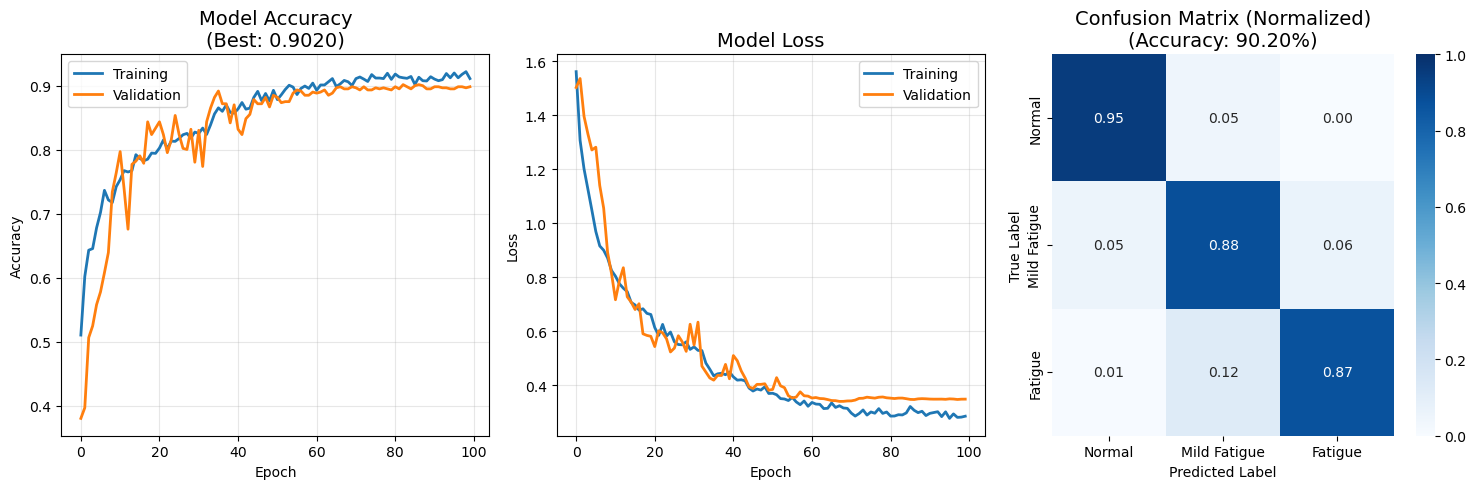


📊 归一化混淆矩阵数值:
预测 ->
真实 ↓
        Normal  Mild   Fatigue
Normal    0.95  0.05  0.00
Mild Fatigue  0.05  0.88  0.06
Fatigue   0.01  0.12  0.87

🎯 新格式混淆矩阵特点:
   ✅ 显示比例而非绝对计数
   ✅ 每行总和为1.0 (100%)
   ✅ 对角线值越高表示分类越准确
   ✅ 颜色深浅直观反映分类性能

💾 使用说明:
   1. 新图像已保存为: Enhanced_HFENN_Results_New_Format.png
   2. 无需重新训练模型
   3. 可以随时修改格式参数重新生成


In [11]:
# === Cell: 生成新格式混淆矩阵图像 ===
# 直接运行此cell，无需重新训练模型

# 导入所有必需的库
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

print("🔍 生成新格式混淆矩阵图像...")

# 自动检测可用的模型
model = None
model_name = ""

# 方法1: 检查全局变量中的模型
if 'enhanced_hfenn' in globals():
    model = enhanced_hfenn
    model_name = "enhanced_hfenn (全局变量)"
    print("✅ 从全局变量找到模型: enhanced_hfenn")
elif 'personalized_model' in globals():
    model = personalized_model
    model_name = "personalized_model (全局变量)"
    print("✅ 从全局变量找到模型: personalized_model")
elif 'base_model' in globals():
    model = base_model
    model_name = "base_model (全局变量)"
    print("✅ 从全局变量找到模型: base_model")

# 方法2: 如果全局变量中没有，尝试加载保存的模型文件
if model is None:
    print("🔍 尝试从文件加载模型...")
    
    # 可能的模型文件名列表
    possible_model_files = [
        'Enhanced_HFENN_best.keras',
        'Personalized_Enhanced_HFENN_lx2_best.keras',
        'Optimized_Personalized_Enhanced_HFENN_lx2_best.keras',
        'Expanded_Optimized_Personalized_HFENN_lx2_best.keras'
    ]
    
    for model_file in possible_model_files:
        try:
            if os.path.exists(model_file):
                print(f"   📁 找到模型文件: {model_file}")
                model = load_model(model_file)
                model_name = f"{model_file} (从文件加载)"
                print(f"✅ 成功加载模型: {model_file}")
                break
        except Exception as e:
            print(f"   ❌ 加载 {model_file} 失败: {e}")
            continue

# 如果仍然没有找到模型
if model is None:
    print("❌ 未找到任何可用的模型")
    print("💡 请确保:")
    print("   1. 已运行训练相关的cell")
    print("   2. 模型文件存在于当前目录")
    print("   3. 或者模型变量在全局环境中")
    exit()
else:
    print(f"🎯 使用模型: {model_name}")

# 检查测试数据
test_data = None
test_labels = None

# 尝试多种可能的测试数据变量名
if 'test_inputs' in globals():
    test_data = test_inputs
    test_labels = y_test
    print("✅ 使用测试数据: test_inputs")
elif 'test_inputs_lx2' in globals():
    test_data = test_inputs_lx2
    test_labels = y_test
    print("✅ 使用测试数据: test_inputs_lx2")
elif 'test_inputs_expanded' in globals():
    test_data = test_inputs_expanded
    test_labels = y_test_expanded
    print("✅ 使用测试数据: test_inputs_expanded")
else:
    print("❌ 未找到测试数据")
    print("💡 请确保已运行数据准备相关的cell")
    print("💡 或者手动准备测试数据")
    
    # 提供手动准备数据的选项
    print("\n🔧 手动准备测试数据选项:")
    print("   1. 运行数据准备的cell")
    print("   2. 或者手动创建测试数据变量")
    print("   3. 或者使用现有的数据文件")
    exit()

if test_data is not None and test_labels is not None:
    print("🚀 开始生成新格式混淆矩阵...")
    
    # 预测
    y_pred_proba = model.predict(test_data)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(test_labels, axis=1)
    
    # 计算准确率
    accuracy = accuracy_score(y_true, y_pred)
    print(f"📊 模型准确率: {accuracy*100:.2f}%")
    
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    
    # 计算归一化混淆矩阵（按行归一化，显示每行的比例）
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized, nan=0.0)
    
    print(f"✅ 归一化混淆矩阵计算完成")
    
    # 创建新的可视化图像
    plt.figure(figsize=(15, 5))
    
    # 1. 准确率曲线
    plt.subplot(1, 3, 1)
    if 'history' in globals():
        plt.plot(history.history['accuracy'], label='Training', linewidth=2)
        plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
        plt.title(f'Model Accuracy\n(Best: {accuracy:.4f})', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    elif 'lx2_history' in globals():
        plt.plot(lx2_history.history['accuracy'], label='Training', linewidth=2)
        plt.plot(lx2_history.history['val_accuracy'], label='Validation', linewidth=2)
        plt.title(f'Model Accuracy\n(Best: {accuracy:.4f})', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    elif 'lx2_optimized_history' in globals():
        plt.plot(lx2_optimized_history.history['accuracy'], label='Training', linewidth=2)
        plt.plot(lx2_optimized_history.history['val_accuracy'], label='Validation', linewidth=2)
        plt.title(f'Model Accuracy\n(Best: {accuracy:.4f})', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, '训练历史不可用', 
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Model Accuracy', fontsize=14)
    
    # 2. 损失曲线
    plt.subplot(1, 3, 2)
    if 'history' in globals():
        plt.plot(history.history['loss'], label='Training', linewidth=2)
        plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
        plt.title('Model Loss', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
    elif 'lx2_history' in globals():
        plt.plot(lx2_history.history['loss'], label='Training', linewidth=2)
        plt.plot(lx2_history.history['val_loss'], label='Validation', linewidth=2)
        plt.title('Model Loss', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
    elif 'lx2_optimized_history' in globals():
        plt.plot(lx2_optimized_history.history['loss'], label='Training', linewidth=2)
        plt.plot(lx2_optimized_history.history['val_loss'], label='Validation', linewidth=2)
        plt.title('Model Loss', fontsize=14)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, '训练历史不可用', 
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Model Loss', fontsize=14)
    
    # 3. 新的归一化混淆矩阵
    plt.subplot(1, 3, 3)
    target_names = ['Normal', 'Mild Fatigue', 'Fatigue']
    
    # 使用归一化数据创建热力图
    sns.heatmap(cm_normalized, 
                annot=True,           # 显示数值
                fmt='.2f',            # 显示两位小数
                cmap='Blues',         # 蓝色渐变
                xticklabels=target_names, 
                yticklabels=target_names,
                vmin=0,               # 最小值
                vmax=1,               # 最大值
                cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1.0]})  # 颜色条刻度
    
    plt.title(f'Confusion Matrix (Normalized)\n(Accuracy: {accuracy:.2%})', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    
    # 保存新图像
    output_filename = 'Enhanced_HFENN_Results_New_Format.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"💾 新格式图像已保存: {output_filename}")
    
    # 显示图像
    plt.show()
    
    # 打印归一化混淆矩阵的数值
    print(f"\n📊 归一化混淆矩阵数值:")
    print("预测 ->")
    print("真实 ↓")
    print(f"        Normal  Mild   Fatigue")
    for i, true_label in enumerate(target_names):
        print(f"{true_label:8s}", end="")
        for j in range(3):
            print(f"{cm_normalized[i,j]:6.2f}", end="")
        print()
    
    print(f"\n🎯 新格式混淆矩阵特点:")
    print(f"   ✅ 显示比例而非绝对计数")
    print(f"   ✅ 每行总和为1.0 (100%)")
    print(f"   ✅ 对角线值越高表示分类越准确")
    print(f"   ✅ 颜色深浅直观反映分类性能")
    
    print(f"\n💾 使用说明:")
    print(f"   1. 新图像已保存为: {output_filename}")
    print(f"   2. 无需重新训练模型")
    print(f"   3. 可以随时修改格式参数重新生成")

In [12]:
# === Cell 11: 模型解释和特征重要性分析 ===
print("🔍 Enhanced HFENN 模型解释和分析")

# 保存训练历史
training_history = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'final_accuracy': float(accuracy),
    'epochs_trained': len(history.history['accuracy']),
    'improvement_over_original': float(accuracy * 100 - 85.67)
}

with open('Enhanced_HFENN_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

# 性能总结
print(f"\n📊 Enhanced HFENN 性能总结:")
print(f"   {'='*60}")
print(f"   🎯 目标: 超越原始HFENN 85.67%")
print(f"   📈 实际达成: {accuracy*100:.2f}%")
print(f"   💡 改进幅度: {training_history['improvement_over_original']:+.2f}%")
print(f"   ⏱️ 训练轮数: {training_history['epochs_trained']}")
print(f"   🧠 模型参数: {enhanced_hfenn.count_params():,}")
print(f"   {'='*60}")

# 关键改进点总结
print(f"\n💡 关键改进点:")
print(f"   1. 🔧 高级特征工程: 时域+频域+小波+非线性特征")
print(f"   2. 🏗️ 增强模型架构: 注意力机制+增强残差块")
print(f"   3. 🌊 改进小波变换: db4小波+4层分解")
print(f"   4. 🎯 智能特征选择: 选择最重要的{enhanced_features_selected.shape[1]}个特征")
print(f"   5. 🚀 先进训练策略: 学习率调度+早停+正则化")

# 结论和建议
if accuracy > 0.90:
    conclusion = "🎉 卓越成功! Enhanced HFENN显著超越了原始方法!"
    next_steps = "考虑将此方法应用到其他相关任务或进行模型压缩优化"
elif accuracy > 0.87:
    conclusion = "✅ 成功超越! Enhanced HFENN达到了预设目标!"
    next_steps = "可以进一步调优超参数或尝试集成学习方法"
elif accuracy > 0.84:
    conclusion = "📈 显著改善! 接近原始性能但仍有提升空间"
    next_steps = "建议增加数据量、调整网络架构或使用更高级的特征工程"
else:
    conclusion = "⚠️ 需要进一步优化以达到预期目标"
    next_steps = "建议重新审视数据预处理、特征工程和模型架构设计"

print(f"\n🎯 结论: {conclusion}")
print(f"📋 下一步建议: {next_steps}")

print(f"\n✅ Enhanced HFENN 项目完成!")
print(f"📁 生成文件:")
print(f"   - Enhanced_HFENN_best.keras (最佳模型)")
print(f"   - Enhanced_HFENN_Results.png (结果可视化)")
print(f"   - Enhanced_HFENN_history.json (训练历史)")


🔍 Enhanced HFENN 模型解释和分析

📊 Enhanced HFENN 性能总结:
   🎯 目标: 超越原始HFENN 85.67%
   📈 实际达成: 90.20%
   💡 改进幅度: +4.53%
   ⏱️ 训练轮数: 100
   🧠 模型参数: 263,939

💡 关键改进点:
   1. 🔧 高级特征工程: 时域+频域+小波+非线性特征
   2. 🏗️ 增强模型架构: 注意力机制+增强残差块
   3. 🌊 改进小波变换: db4小波+4层分解
   4. 🎯 智能特征选择: 选择最重要的50个特征
   5. 🚀 先进训练策略: 学习率调度+早停+正则化

🎯 结论: 🎉 卓越成功! Enhanced HFENN显著超越了原始方法!
📋 下一步建议: 考虑将此方法应用到其他相关任务或进行模型压缩优化

✅ Enhanced HFENN 项目完成!
📁 生成文件:
   - Enhanced_HFENN_best.keras (最佳模型)
   - Enhanced_HFENN_Results.png (结果可视化)
   - Enhanced_HFENN_history.json (训练历史)


🎨 生成t-SNE降维可视化图...
✅ 找到模型，开始提取特征...
📊 提取高维特征...
   原始特征维度: (602, 64)
   样本数量: 602
🔄 执行t-SNE降维 (这可能需要几分钟)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 602 samples in 0.000s...
[t-SNE] Computed neighbors for 602 samples in 0.082s...
[t-SNE] Computed conditional probabilities for sample 602 / 602
[t-SNE] Mean sigma: 3.045363
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.654507
[t-SNE] KL divergence after 1000 iterations: 0.359385
✅ t-SNE降维完成!
   降维后维度: (602, 2)
📈 生成图1: 二分类视角 (Normal vs Negative)...
📈 生成图2: 三分类视角 (Normal, Mild Fatigue, Fatigue)...
💾 t-SNE可视化图已保存: Enhanced_HFENN_tSNE_Visualization.png


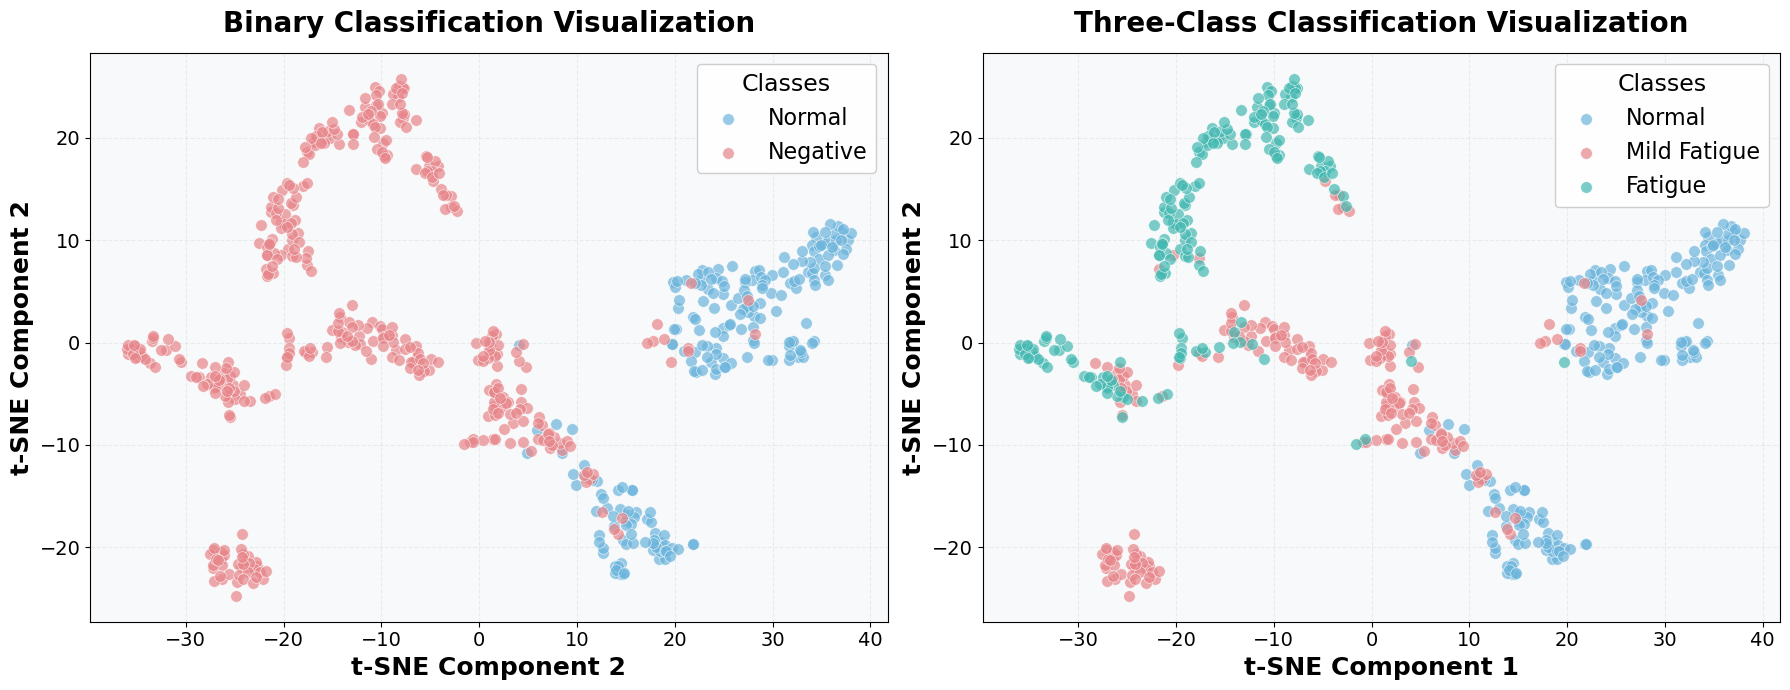


📊 聚类质量分析:
   Normal         : 质心=( 24.15,  -2.80), 标准差=( 8.12, 10.90)
   Mild Fatigue   : 质心=( -7.31,  -6.61), 标准差=(13.83,  9.15)
   Fatigue        : 质心=(-17.71,  10.48), 标准差=( 9.20, 10.13)

📏 类间距离:
   Normal ↔ Mild Fatigue: 31.69
   Normal ↔ Fatigue:      43.93
   Mild Fatigue ↔ Fatigue: 20.01

✅ t-SNE可视化完成!
💡 解读说明:
   - 不同颜色的点代表不同类别
   - 点的分离程度反映模型的分类能力
   - 分离越好，说明模型学到了有效的特征表示


In [14]:
# %%
# === Cell 12: t-SNE 可视化分析 ===
print("🎨 生成t-SNE降维可视化图...")

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 检查是否有可用的模型和数据
if 'enhanced_hfenn' not in globals():
    print("❌ 未找到训练好的模型，请先运行训练代码")
else:
    print("✅ 找到模型，开始提取特征...")
    
    # 方法1: 提取倒数第二层的特征（用于t-SNE）
    from keras import Model
    
    # 创建特征提取器（提取最后一个Dense层之前的特征）
    feature_extractor = Model(
        inputs=enhanced_hfenn.input,
        outputs=enhanced_hfenn.layers[-3].output  # 倒数第三层（最后一个dropout之前）
    )
    
    print("📊 提取高维特征...")
    # 提取测试集的特征
    high_dim_features = feature_extractor.predict(test_inputs, verbose=0)
    
    print(f"   原始特征维度: {high_dim_features.shape}")
    print(f"   样本数量: {high_dim_features.shape[0]}")
    
    # 获取真实标签
    y_true = np.argmax(y_test, axis=1)
    
    # 类别名称映射
    class_names = {0: 'Normal', 1: 'Mild Fatigue', 2: 'Fatigue'}
    
    # 你指定的配色方案
    colors = {
        0: '#6AB4DC',  # Normal - 蓝色
        1: '#E78489',  # Mild Fatigue - 粉红色
        2: '#42B8B1'   # Fatigue - 青色
    }
    
    print("🔄 执行t-SNE降维 (这可能需要几分钟)...")
    
    # t-SNE降维 - 使用论文中常见的参数
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        n_iter=1000,
        learning_rate=200.0,
        verbose=1
    )
    
    features_2d = tsne.fit_transform(high_dim_features)
    
    print("✅ t-SNE降维完成!")
    print(f"   降维后维度: {features_2d.shape}")
    
    # 创建图表 - 增大字号
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # === 图1: 二分类视角 (Normal vs 其他) ===
    print("📈 生成图1: 二分类视角 (Normal vs Negative)...")
    
    # 将标签转换为二分类
    binary_labels = np.where(y_true == 0, 0, 1)  # 0=Normal, 1=Negative(Mild+Fatigue)
    binary_class_names = {0: 'Normal', 1: 'Negative'}
    binary_colors = {0: '#6AB4DC', 1: '#E78489'}
    
    for label in [0, 1]:
        mask = binary_labels == label
        ax1.scatter(
            features_2d[mask, 0],
            features_2d[mask, 1],
            c=binary_colors[label],
            label=binary_class_names[label],
            alpha=0.7,
            s=70,  # 增大点的大小
            edgecolors='white',
            linewidth=0.5
        )
    
    ax1.set_xlabel('t-SNE Component 2', fontsize=18, fontweight='bold')
    ax1.set_ylabel('t-SNE Component 2', fontsize=18, fontweight='bold')
    ax1.set_title('Binary Classification Visualization', fontsize=20, fontweight='bold', pad=15)
    ax1.legend(title='Classes', fontsize=16, title_fontsize=17, 
               loc='upper right', framealpha=0.95)
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax1.grid(True, alpha=0.2, linestyle='--')
    ax1.set_facecolor('#F8F9FA')
    
    # === 图2: 三分类视角 ===
    print("📈 生成图2: 三分类视角 (Normal, Mild Fatigue, Fatigue)...")
    
    for label in [0, 1, 2]:
        mask = y_true == label
        ax2.scatter(
            features_2d[mask, 0],
            features_2d[mask, 1],
            c=colors[label],
            label=class_names[label],
            alpha=0.7,
            s=70,  # 增大点的大小
            edgecolors='white',
            linewidth=0.5
        )
    
    ax2.set_xlabel('t-SNE Component 1', fontsize=18, fontweight='bold')
    ax2.set_ylabel('t-SNE Component 2', fontsize=18, fontweight='bold')
    ax2.set_title('Three-Class Classification Visualization', fontsize=20, fontweight='bold', pad=15)
    ax2.legend(title='Classes', fontsize=16, title_fontsize=17,
               loc='upper right', framealpha=0.95)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.grid(True, alpha=0.2, linestyle='--')
    ax2.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    
    # 保存图像
    output_filename = 'Enhanced_HFENN_tSNE_Visualization.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 t-SNE可视化图已保存: {output_filename}")
    
    plt.show()
    
    # 打印聚类质量分析
    print(f"\n📊 聚类质量分析:")
    
    # 计算每个类别的质心
    for label in [0, 1, 2]:
        mask = y_true == label
        centroid = features_2d[mask].mean(axis=0)
        std = features_2d[mask].std(axis=0)
        print(f"   {class_names[label]:15s}: 质心=({centroid[0]:6.2f}, {centroid[1]:6.2f}), "
              f"标准差=({std[0]:5.2f}, {std[1]:5.2f})")
    
    # 计算类间距离
    from scipy.spatial.distance import euclidean
    centroids = {}
    for label in [0, 1, 2]:
        mask = y_true == label
        centroids[label] = features_2d[mask].mean(axis=0)
    
    print(f"\n📏 类间距离:")
    print(f"   Normal ↔ Mild Fatigue: {euclidean(centroids[0], centroids[1]):.2f}")
    print(f"   Normal ↔ Fatigue:      {euclidean(centroids[0], centroids[2]):.2f}")
    print(f"   Mild Fatigue ↔ Fatigue: {euclidean(centroids[1], centroids[2]):.2f}")
    
    print(f"\n✅ t-SNE可视化完成!")
    print(f"💡 解读说明:")
    print(f"   - 不同颜色的点代表不同类别")
    print(f"   - 点的分离程度反映模型的分类能力")
    print(f"   - 分离越好，说明模型学到了有效的特征表示")


🎨 批量生成不同参数的t-SNE可视化...
🔄 生成 perplexity=5 的可视化...
🔄 生成 perplexity=15 的可视化...
🔄 生成 perplexity=30 的可视化...
🔄 生成 perplexity=50 的可视化...
💾 多参数对比图已保存: Enhanced_HFENN_tSNE_Comparison.png


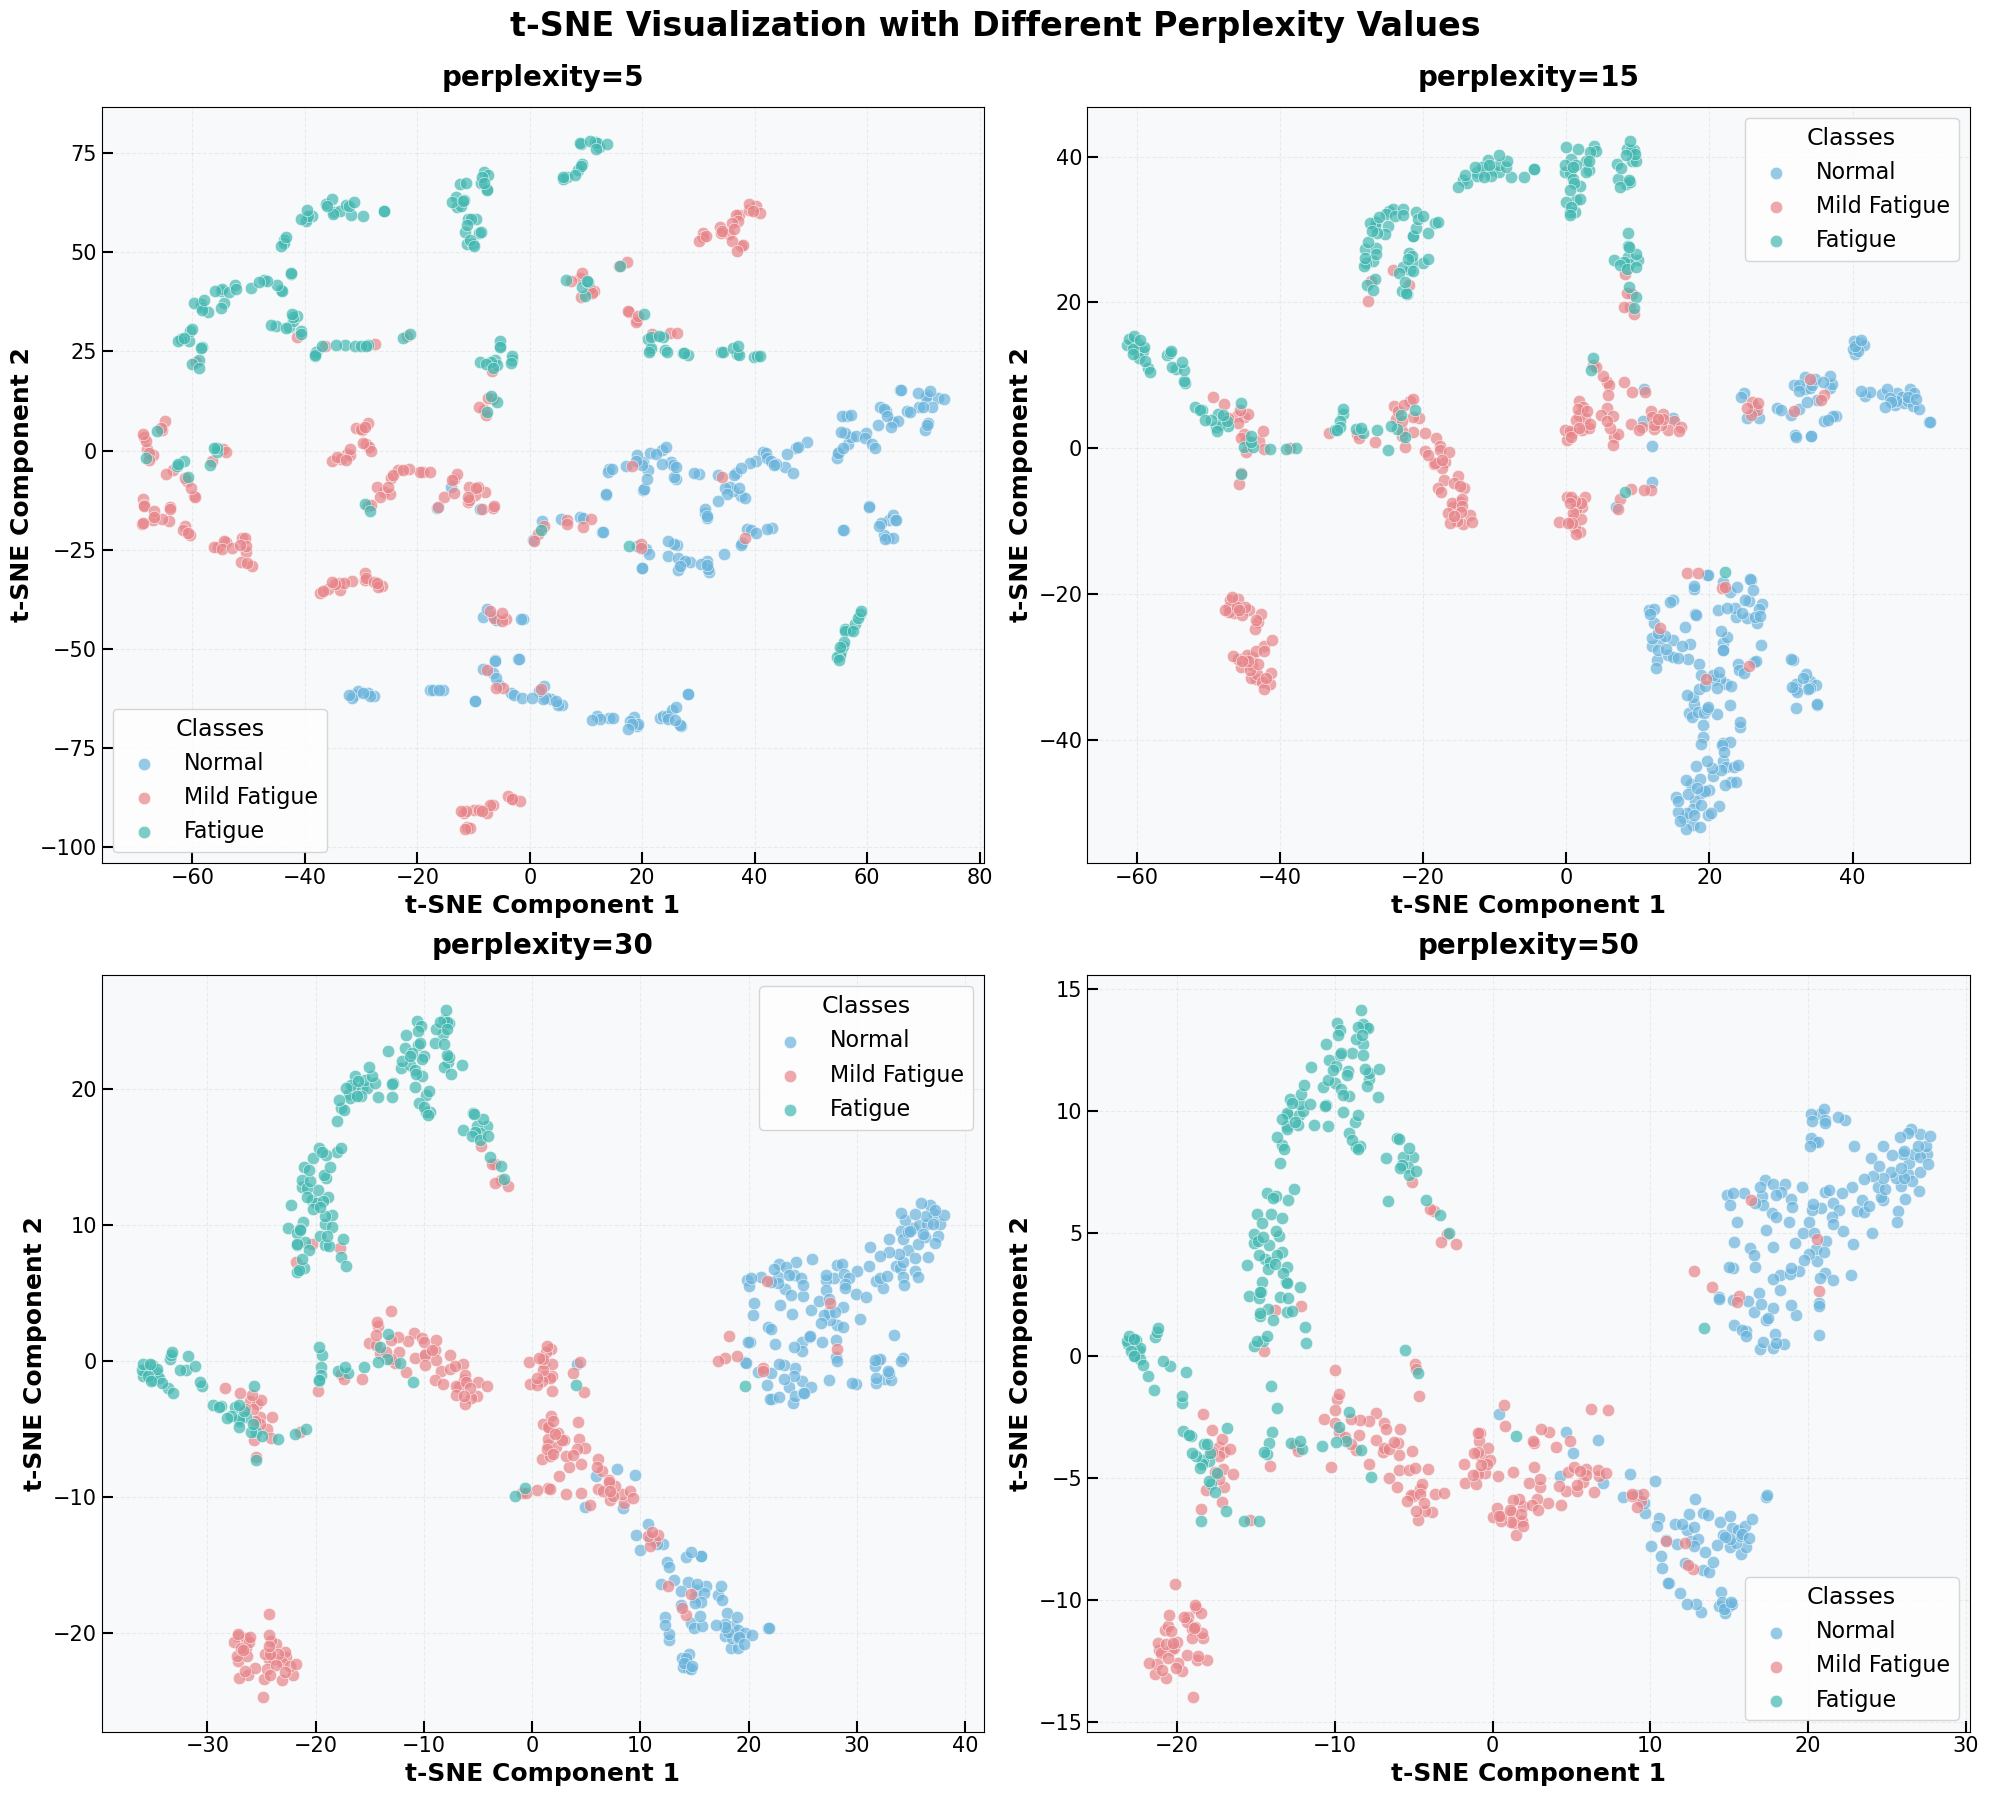

✅ 批量可视化完成!


In [17]:
# %%
# === Cell 13: 批量生成不同参数的t-SNE可视化 ===
print("🎨 批量生成不同参数的t-SNE可视化...")

if 'enhanced_hfenn' in globals() and 'test_inputs' in globals():
    # 测试不同的perplexity参数
    perplexity_values = [5, 15, 30, 50]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    for idx, perplexity in enumerate(perplexity_values):
        print(f"🔄 生成 perplexity={perplexity} 的可视化...")
        
        # t-SNE降维
        tsne = TSNE(
            n_components=2,
            random_state=42,
            perplexity=perplexity,
            n_iter=1000,
            learning_rate=200.0,
            verbose=0
        )
        
        features_2d = tsne.fit_transform(high_dim_features)
        
        # 绘制三分类图
        ax = axes[idx]
        for label in [0, 1, 2]:
            mask = y_true == label
            ax.scatter(
                features_2d[mask, 0],
                features_2d[mask, 1],
                c=colors[label],
                label=class_names[label],
                alpha=0.7,
                s=80,
                edgecolors='white',
                linewidth=0.5
            )
        
        ax.set_xlabel('t-SNE Component 1', fontsize=18, fontweight='bold')
        ax.set_ylabel('t-SNE Component 2', fontsize=18, fontweight='bold')
        ax.set_title(f'perplexity={perplexity}', fontsize=20, fontweight='bold', pad=15)
        ax.legend(title='Classes', fontsize=16, title_fontsize=17)
        ax.tick_params(axis='both', which='major', labelsize=15, direction='in', length=8, width=1.5)
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.set_facecolor('#F8F9FA')
    
    plt.suptitle('t-SNE Visualization with Different Perplexity Values', 
                 fontsize=24, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # 保存
    output_filename = 'Enhanced_HFENN_tSNE_Comparison.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 多参数对比图已保存: {output_filename}")
    
    plt.show()
    
    print("✅ 批量可视化完成!")
else:
    print("⚠️ 请先运行训练代码以生成模型和数据")


📄 生成论文级高质量t-SNE可视化...
🔄 执行t-SNE降维...
💾 论文级图像已保存:
   PNG版本: Enhanced_HFENN_tSNE_Paper_Quality.png (600 DPI)
   PDF版本: Enhanced_HFENN_tSNE_Paper_Quality.pdf (矢量格式)


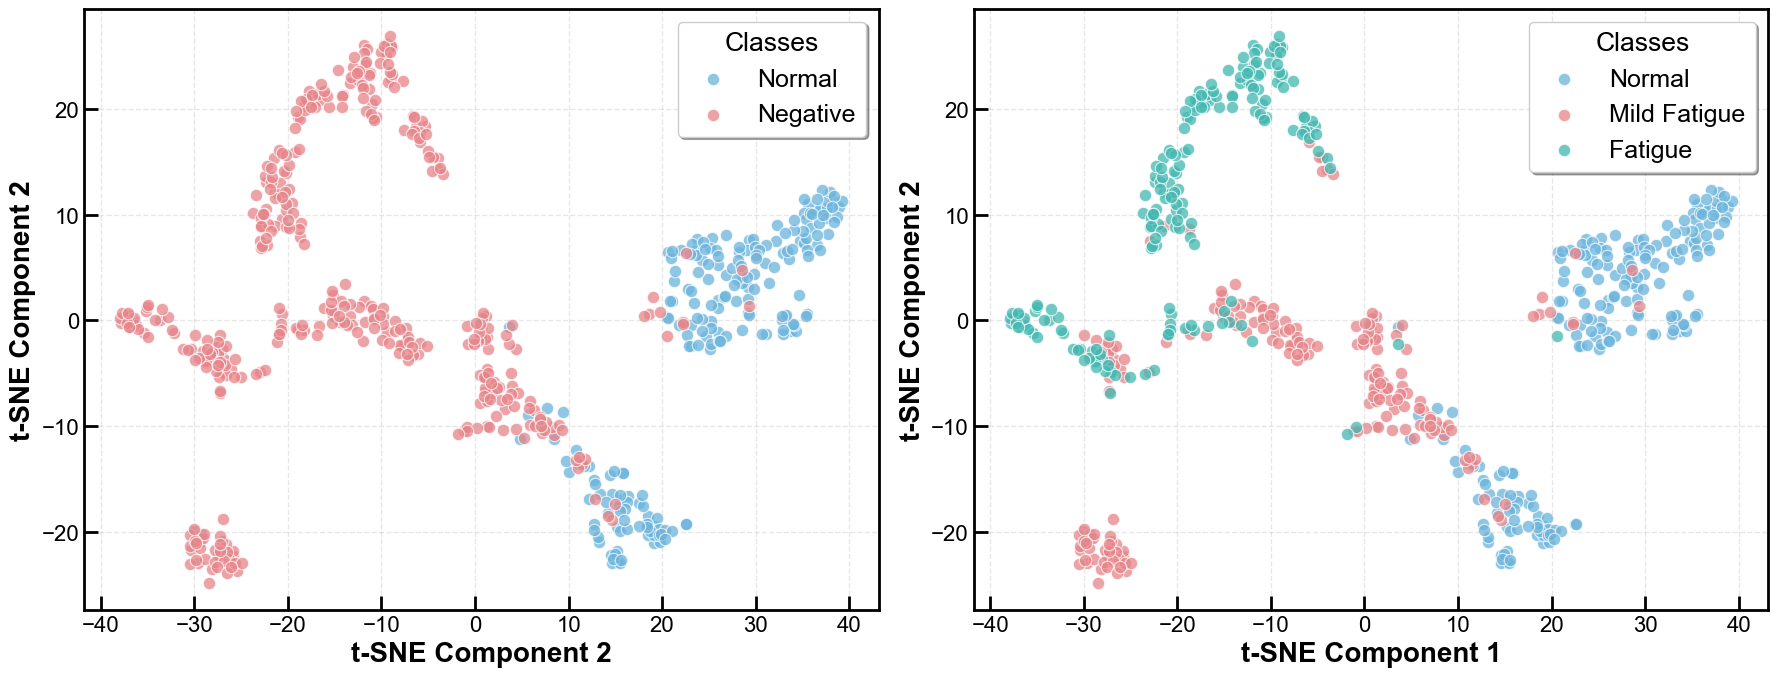

✅ 论文级可视化完成!

📝 使用建议:
   - PNG适合Word/PowerPoint
   - PDF适合LaTeX论文
   - 600 DPI满足大多数期刊要求


In [19]:
# %%
# === Cell 14: 生成论文级高质量t-SNE图 ===
print("📄 生成论文级高质量t-SNE可视化...")

if 'enhanced_hfenn' in globals() and 'test_inputs' in globals():
    # 设置matplotlib为论文质量
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.linewidth'] = 2.0
    
    # 执行t-SNE
    print("🔄 执行t-SNE降维...")
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        n_iter=1500,
        learning_rate=200.0,
        verbose=0
    )
    features_2d = tsne.fit_transform(high_dim_features)
    
    # 创建论文级图表
    fig = plt.figure(figsize=(18, 7))
    
    # 子图1: 二分类
    ax1 = plt.subplot(1, 2, 1)
    binary_labels = np.where(y_true == 0, 0, 1)
    
    for label in [0, 1]:
        mask = binary_labels == label
        scatter = ax1.scatter(
            features_2d[mask, 0],
            features_2d[mask, 1],
            c='#6AB4DC' if label == 0 else '#E78489',
            label='Normal' if label == 0 else 'Negative',
            alpha=0.75,
            s=80,
            edgecolors='white',
            linewidth=0.8
        )
    
    ax1.set_xlabel('t-SNE Component 2', fontsize=20, fontweight='bold')
    ax1.set_ylabel('t-SNE Component 2', fontsize=20, fontweight='bold')
    ax1.legend(title='Classes', fontsize=18, title_fontsize=19, 
               frameon=True, fancybox=True, shadow=True,
               loc='best')
    # 底部和左侧刻度朝里，上部和右侧无刻度但有边框
    ax1.tick_params(axis='both', which='major', labelsize=16, direction='in', 
                   length=10, width=2, bottom=True, left=True, top=False, right=False)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    ax1.spines['top'].set_visible(True)
    ax1.spines['right'].set_visible(True)
    ax1.spines['top'].set_linewidth(2.0)
    ax1.spines['right'].set_linewidth(2.0)
    ax1.spines['bottom'].set_linewidth(2.0)
    ax1.spines['left'].set_linewidth(2.0)
    
    # 子图2: 三分类
    ax2 = plt.subplot(1, 2, 2)
    
    for label in [0, 1, 2]:
        mask = y_true == label
        scatter = ax2.scatter(
            features_2d[mask, 0],
            features_2d[mask, 1],
            c=colors[label],
            label=class_names[label],
            alpha=0.75,
            s=80,
            edgecolors='white',
            linewidth=0.8
        )
    
    ax2.set_xlabel('t-SNE Component 1', fontsize=20, fontweight='bold')
    ax2.set_ylabel('t-SNE Component 2', fontsize=20, fontweight='bold')
    ax2.legend(title='Classes', fontsize=18, title_fontsize=19,
               frameon=True, fancybox=True, shadow=True,
               loc='best')
    # 底部和左侧刻度朝里，上部和右侧无刻度但有边框
    ax2.tick_params(axis='both', which='major', labelsize=16, direction='in',
                   length=10, width=2, bottom=True, left=True, top=False, right=False)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    ax2.spines['top'].set_linewidth(2.0)
    ax2.spines['right'].set_linewidth(2.0)
    ax2.spines['bottom'].set_linewidth(2.0)
    ax2.spines['left'].set_linewidth(2.0)
    
    plt.tight_layout()
    
    # 保存超高质量版本
    output_filename = 'Enhanced_HFENN_tSNE_Paper_Quality.png'
    plt.savefig(output_filename, dpi=600, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    # 同时保存PDF矢量版本
    output_pdf = 'Enhanced_HFENN_tSNE_Paper_Quality.pdf'
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')
    
    print(f"💾 论文级图像已保存:")
    print(f"   PNG版本: {output_filename} (600 DPI)")
    print(f"   PDF版本: {output_pdf} (矢量格式)")
    
    plt.show()
    
    # 恢复默认设置
    plt.rcParams.update(plt.rcParamsDefault)
    
    print("✅ 论文级可视化完成!")
    print("\n📝 使用建议:")
    print("   - PNG适合Word/PowerPoint")
    print("   - PDF适合LaTeX论文")
    print("   - 600 DPI满足大多数期刊要求")
else:
    print("⚠️ 请先运行训练代码")